# 01. Exploración y preprocesamiento base

Este notebook corresponde al punto 3 del documento: verifica la estructura del dataset, revisa ejemplos visuales y deja listo un preprocesamiento básico para continuar después con el modelado.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

Ruta detectada: c:\Users\alfam\proyPercepcion
Train existe: True
Test existe: True
freshapples: 1693
freshbanana: 1581
freshoranges: 1466
rottenapples: 2342
rottenbanana: 2224
rottenoranges: 1595


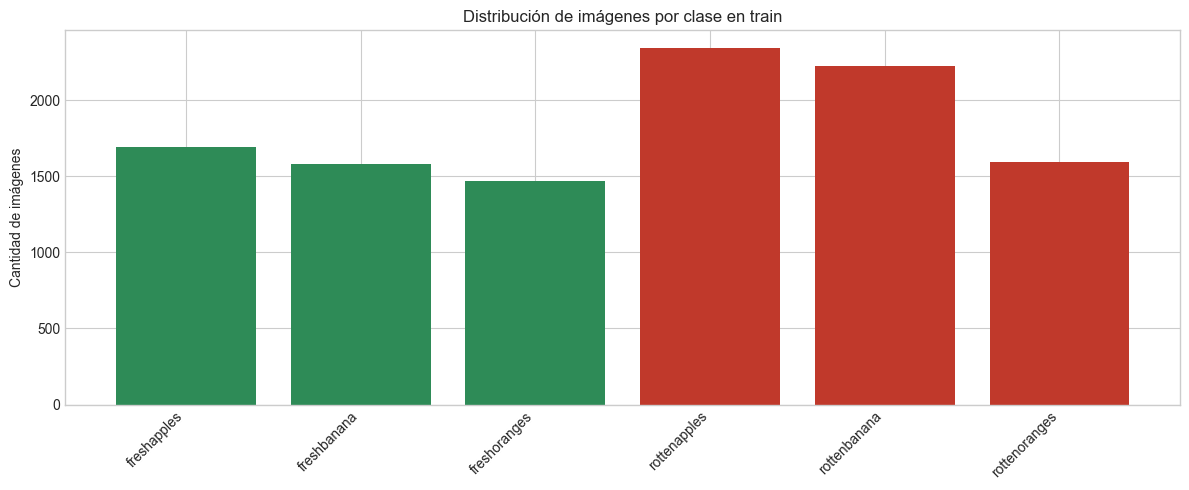

In [7]:
from pathlib import Path

project_root_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r'C:\Users\alfam\proyPercepcion'),
    Path(r'C:\Users\alfam\proyPercepcion\notebooks').parent,
 ]
project_root = None
for candidate in project_root_candidates:
    if (candidate / 'data' / 'train').exists() and (candidate / 'data' / 'test').exists():
        project_root = candidate
        break

if project_root is None:
    project_root = Path(r'C:\Users\alfam\proyPercepcion')

data_dir = project_root / 'data'
train_dir = data_dir / 'train'
test_dir = data_dir / 'test'

print(f'Ruta detectada: {project_root}')
print(f'Train existe: {train_dir.exists()}')
print(f'Test existe: {test_dir.exists()}')

if train_dir.exists():
    train_classes = sorted([p for p in train_dir.iterdir() if p.is_dir()])
    counts = {cls.name: len(list(cls.iterdir())) for cls in train_classes}
    for class_name, count in counts.items():
        print(f'{class_name}: {count}')

    plt.figure(figsize=(12, 5))
    colors = ['#2e8b57' if 'fresh' in name.lower() else '#c0392b' for name in counts.keys()]
    plt.bar(counts.keys(), counts.values(), color=colors)
    plt.title('Distribución de imágenes por clase en train')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Cantidad de imágenes')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró data/train todavía.')

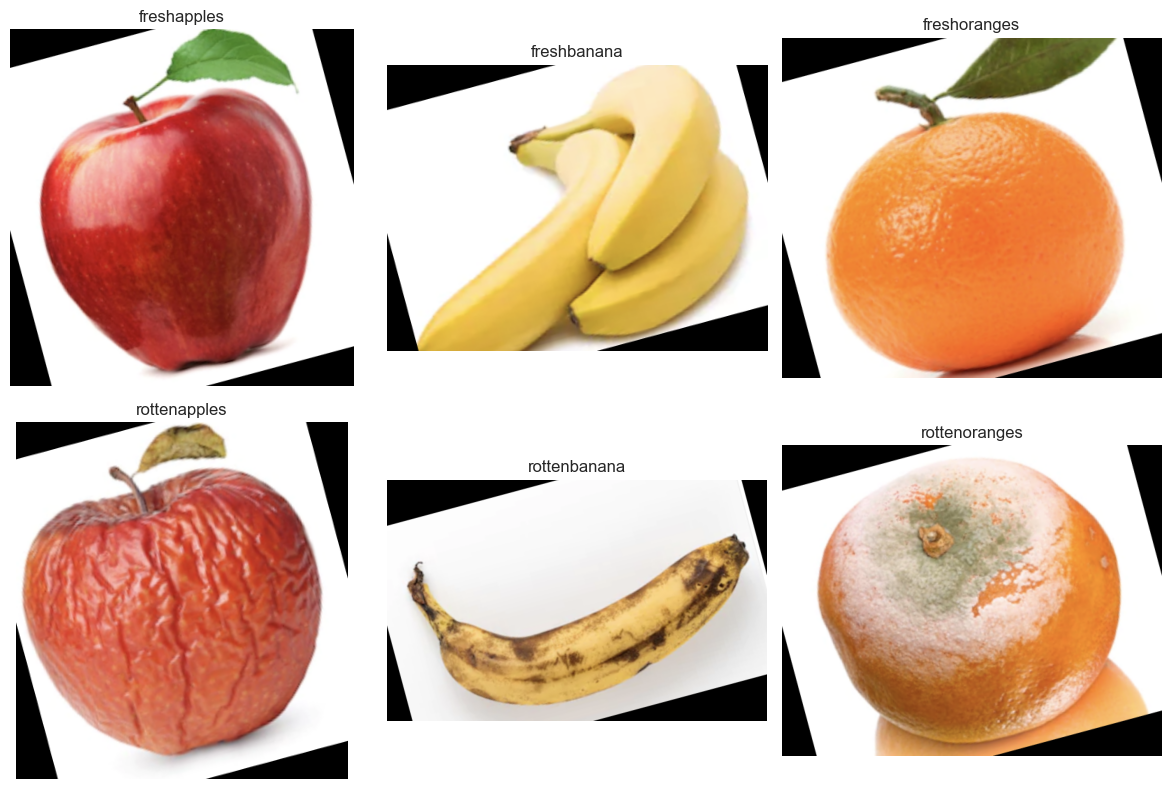

In [8]:
if train_dir.exists():
    sample_classes = sorted([p for p in train_dir.iterdir() if p.is_dir()])[:6]
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for idx, cls in enumerate(sample_classes):
        images = list(cls.iterdir())
        if not images:
            axes[idx].set_title(f'{cls.name} (vacía)')
            axes[idx].axis('off')
            continue

        image_path = images[0]
        image = Image.open(image_path)
        axes[idx].imshow(image)
        axes[idx].set_title(cls.name)
        axes[idx].axis('off')

    for idx in range(len(sample_classes), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('No hay imágenes para mostrar todavía.')

In [9]:
def cargar_imagen(ruta_img, size=(224, 224)):
    """Carga una imagen y la estandariza a RGB y al tamaño definido."""
    img = Image.open(ruta_img).convert('RGB')
    img = img.resize(size)
    return np.array(img)

def normalizar_imagen(img_array):
    """Convierte la imagen a float32 en rango [0, 1]."""
    return img_array.astype(np.float32) / 255.0

def preprocesar_imagen(ruta_img, size=(224, 224)):
    """Pipeline base: carga, resize y normalización."""
    img = cargar_imagen(ruta_img, size=size)
    return normalizar_imagen(img)

print('Funciones de preprocesamiento definidas correctamente.')

Funciones de preprocesamiento definidas correctamente.


Imagen 1 (original): c:\Users\alfam\proyPercepcion\data\train\freshapples\rotated_by_15_Screen Shot 2018-06-08 at 4.59.36 PM.png
Imagen 1 preprocesada: shape=(224, 224, 3) range=0.0000-1.0000
Imagen 2 (original): c:\Users\alfam\proyPercepcion\data\train\freshapples\rotated_by_15_Screen Shot 2018-06-08 at 4.59.36 PM.png
Imagen 2 preprocesada: shape=(224, 224, 3) range=0.0000-1.0000


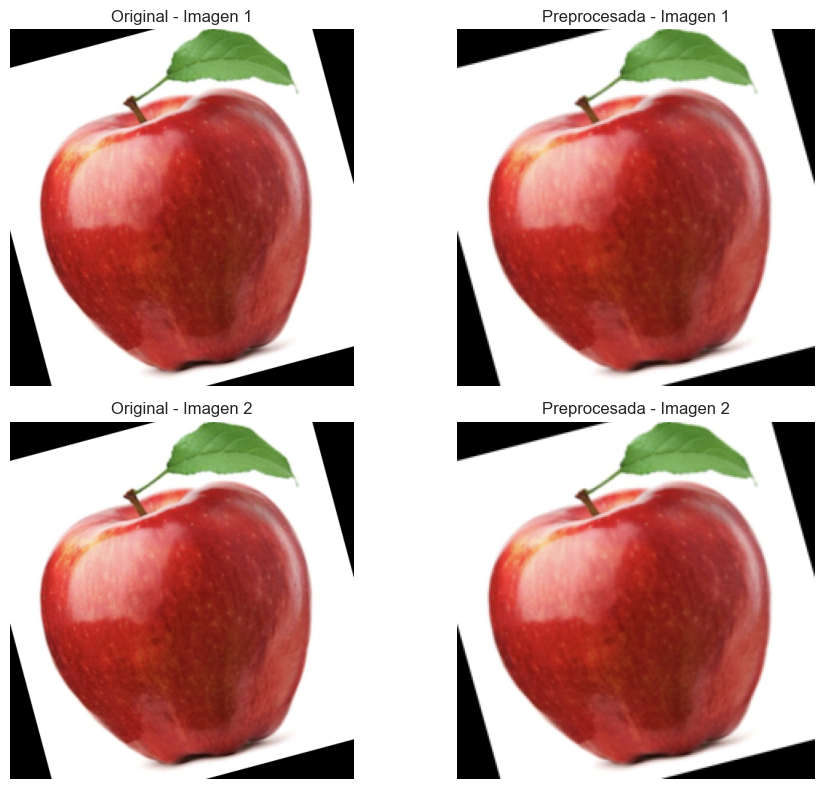

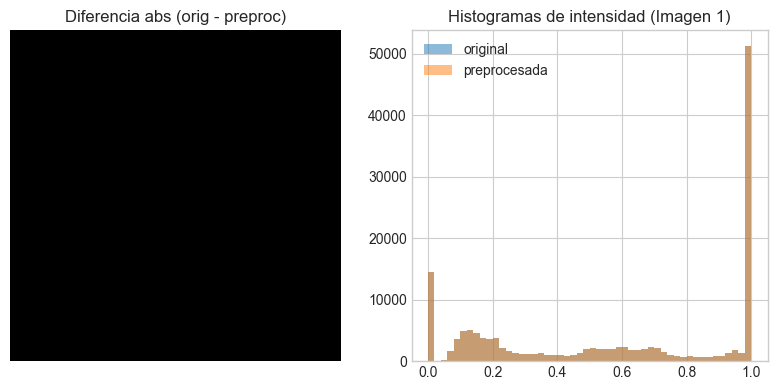

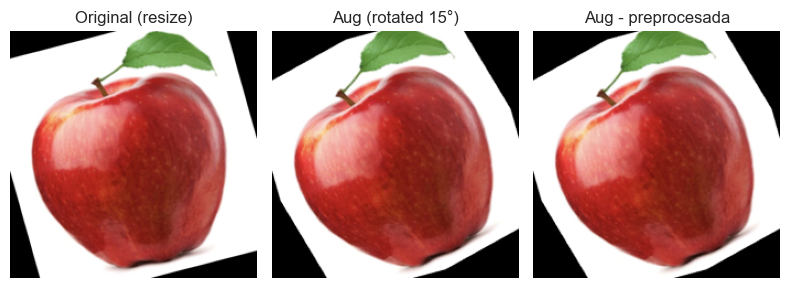

In [11]:
if train_dir.exists():
    first_class = next(p for p in sorted(train_dir.iterdir()) if p.is_dir())
    images = sorted(list(first_class.iterdir()))

    if len(images) < 2:
        print('No hay suficientes imágenes en la clase para la comparación.')
    else:
        img_path1 = images[0]
        img_path2 = next((p for p in images if 'rotated' in p.name.lower()), images[1])

        # Originales (PIL) y preprocesadas (numpy normalizada)
        orig1 = Image.open(img_path1).convert('RGB')
        proc1 = preprocesar_imagen(img_path1)

        orig2 = Image.open(img_path2).convert('RGB')
        proc2 = preprocesar_imagen(img_path2)

        print(f'Imagen 1 (original): {img_path1}')
        print(f'Imagen 1 preprocesada: shape={proc1.shape} range={proc1.min():.4f}-{proc1.max():.4f}')
        print(f'Imagen 2 (original): {img_path2}')
        print(f'Imagen 2 preprocesada: shape={proc2.shape} range={proc2.min():.4f}-{proc2.max():.4f}')

        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes[0, 0].imshow(orig1)
        axes[0, 0].set_title('Original - Imagen 1')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(proc1)
        axes[0, 1].set_title('Preprocesada - Imagen 1')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(orig2)
        axes[1, 0].set_title('Original - Imagen 2')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(proc2)
        axes[1, 1].set_title('Preprocesada - Imagen 2')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        # Mostrar diferencia entre original (resize) y preprocesada
        orig1_resized = orig1.resize((proc1.shape[1], proc1.shape[0]))
        orig1_np = np.array(orig1_resized).astype(np.float32) / 255.0
        diff1 = np.clip(np.abs(orig1_np - proc1), 0, 1)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(diff1)
        plt.title('Diferencia abs (orig - preproc)')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.hist(orig1_np.ravel(), bins=50, alpha=0.5, label='original')
        plt.hist(proc1.ravel(), bins=50, alpha=0.5, label='preprocesada')
        plt.legend()
        plt.title('Histogramas de intensidad (Imagen 1)')
        plt.tight_layout()
        plt.show()

        # Mostrar augmentación simulada (rotación) para visualizar efecto
        aug = orig1.rotate(15)
        aug_resized = aug.resize((proc1.shape[1], proc1.shape[0]))
        aug_proc = normalizar_imagen(np.array(aug_resized))

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(orig1_resized)
        plt.title('Original (resize)')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(aug_resized)
        plt.title('Aug (rotated 15°)')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(aug_proc)
        plt.title('Aug - preprocesada')
        plt.axis('off')

        plt.tight_layout()
        plt.show()
else:
    print('No se puede hacer la prueba porque falta data/train.')